In [59]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import xarray as xr
from numpy.typing import NDArray
from rich.console import Console
from rich.table import Table
from scipy.ndimage import median_filter
from scipy.stats import distributions

In [60]:
FIG_SAVE_FMT = "png"

In [61]:
NOTEBOOK_DIR = Path().cwd().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = (
    DATA_DIR / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2025-07-26_with_dndt_resampled.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-09-15_with_dndt_resampled.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"
VEL_PATH = DATA_DIR / "NH10_Mooring_Data/nh10_hourly_data_1997_2021_rotated_filtered_streamwise_v5.nc"
GEBCO_PATH = list(Path(DATA_DIR / "GEBCO/").glob("*.nc"))

VELOCITY_VARIABLE = (
    "cs_proj"  # cs for cross-shelf with depth mean subtraced; cs_proj for cross-shelf projected by McCabe et al 2015
)

In [ ]:
def calculate_budget_volume(
    da: xr.DataArray,
    d_min: float,
    d_max: float,
    d_step: float,
    lon_min: float,
    lon_max: float,
    lat: float,
) -> xr.DataArray:
    """Calculate the volume of a control volume on the NHL.

    Args:
        da (xr.DataArray): DataArray with dimensions (time, distance_from_shore, lat, lon).
        d_min (float): Minimum depth in meters.
        d_max (float): Maximum depth in meters.
        d_step (float): Depth step in meters.
        lon_min (float): Minimum longitude of the control volume.
        lon_max (float): Maximum longitude of the control volume.
        lat (float): Latitude of the control volume.

    Returns:
        xr.DataArray: DataArray with the volume of the control volume at each time step.


    """
    bathymetry = xr.open_mfdataset(GEBCO_PATH).interp(lat=lat).interp({"lon": np.linspace(lon_min, lon_max, int(1e6))})
    coast = bathymetry.isel({"lon": np.nanargmin(np.abs(bathymetry.elevation.values))})

    bathymetry["distance_from_shore"] = xr.apply_ufunc(
        lambda x: haversine(
            bathymetry.lon[0].values,
            coast.lat.values,
            x,
            coast.lat.values,
        )
        - haversine(
            bathymetry.lon[0].values,
            coast.lat.values,
            coast.lon.values,
            coast.lat.values,
        ),
        bathymetry.lon,
    )
    bathymetry = bathymetry.swap_dims({"lon": "distance_from_shore"}).load()
    elevation = bathymetry.interp(
        distance_from_shore=np.arange(d_min, d_max, d_step),
        method="linear",
    )["elevation"]  # convert to m
    out = -elevation * d_step * da * 1000
    out = out.sum(dim="distance_from_shore")
    return out


def haversine(lon1: float, lat1: float, lon2: float, lat2: float) -> float:
    """Calculate the great circle distance between two points on the earth (specified in decimal degrees).

    Args:
        lon1 (scalar): longitude of first point
        lat1 (scalar): latitude of first point
        lon2 (scalar): longitude of second point
        lat2 (scalar): latitude of second point

    Returns:
        scalar: distance in km between (lon1, lat1) and (lon2, lat2)

    """
    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km

In [63]:
inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)
wind = xr.open_dataset(WIND_PATH, decode_timedelta=True)
velocity = xr.open_dataset(VEL_PATH).resample(time="1D").mean()

velocity = velocity.where(velocity.depth > 10, drop=True)  # drop depths above 10m

# bit of a lazy way to use the cs_proj variable, since the notebook is set up for cs
if VELOCITY_VARIABLE == "cs_proj":
    velocity = velocity.drop_vars("cs").rename({"cs_proj": "cs"})

# resample midshelf nitrate to fill some of the gaps for composite calclulations
midshelf_nitrate = midshelf_nitrate.resample(time="1D").mean()

# interpolate velocity depths to match 1 meter bins in midshelf nitrate
velocity = velocity.interp(depth=midshelf_nitrate.depth)
velocity = velocity.where(velocity.depth > 10, drop=True)  # drop depths above 10m

# calculate monthly means for midshelf nitrate
midshelf_nitrate_monthly = xr.Dataset(
    {
        "mean": midshelf_nitrate.groupby("time.month").mean(dim="time", skipna=True)["nitrate"],
        "std": midshelf_nitrate.groupby("time.month").std(dim="time", skipna=True)["nitrate"],
        "count": midshelf_nitrate.groupby("time.month").count(dim="time")["nitrate"],
    },
)
midshelf_nitrate_monthly["ci"] = midshelf_nitrate_monthly["std"] / np.sqrt(5) * distributions.t(5 - 1).isf(0.025)

# manually calculate this for now until I can fix it in the nitrate processing script
inner_nitrate["dndt"] = inner_nitrate["nitrate"].mean(dim="depth").differentiate("time", datetime_unit="s")
midshelf_nitrate["dndt"] = midshelf_nitrate["nitrate"].mean(dim="depth").differentiate("time", datetime_unit="s")

inner_nitrate["dndt_volume_integrated"] = calculate_budget_volume(
    inner_nitrate.dndt,
    d_min=-7,
    d_max=0,
    d_step=0.1,
    lon_min=-130,
    lon_max=-120,
    lat=44.66,
)
midshelf_nitrate["dndt_volume_integrated"] = calculate_budget_volume(
    midshelf_nitrate.dndt,
    d_min=-18.5,
    d_max=-7,
    d_step=0.1,
    lon_min=-130,
    lon_max=-120,
    lat=44.66,
)
inner_nitrate["dndt_volume_integrated"] = inner_nitrate["dndt_volume_integrated"].where(
    ~np.isnan(inner_nitrate["dndt"]),
)
midshelf_nitrate["dndt_volume_integrated"] = midshelf_nitrate["dndt_volume_integrated"].where(
    ~np.isnan(midshelf_nitrate["dndt"]),
)
inner_nitrate["dndt_volume_integrated_filtered"] = (
    ["time"],
    median_filter(inner_nitrate["dndt_volume_integrated"].values, size=8),
)
midshelf_nitrate["dndt_volume_integrated_filtered"] = (
    ["time"],
    median_filter(midshelf_nitrate["dndt_volume_integrated"].values, size=8),
)

## "Normal" Budget Calculation Method

In [ ]:
# calculate midshelf flux by interpolating nan and filling ends with constant extrapolation
midshelf_nitrate_interp = xr.concat(
    [
        yi.interpolate_na(
            "depth",
            fill_value=[yi.dropna("depth")[0], yi.dropna("depth")[-1]],
        )
        for yi in midshelf_nitrate.nitrate
        if yi.dropna("depth").size > 40  # only use profiles with more than 40 depth points
    ],
    "time",
)
cs_al_midnitr, midnitr_al_cs = xr.align(
    velocity.cs.dropna("time", how="all"),
    midshelf_nitrate_interp,
)
midshelf_nitrate_flux_depth_integrated = xr.apply_ufunc(
    lambda x, y: np.array(
        [np.trapezoid(yi[~np.isnan(yi)], x[~np.isnan(yi)]) for yi in y],
    ),
    cs_al_midnitr.depth.values,
    (cs_al_midnitr * midnitr_al_cs).values,
)
midshelf_nitrate_flux_depth_integrated = xr.DataArray(
    midshelf_nitrate_flux_depth_integrated,
    {"time": cs_al_midnitr.time},
)
midshelf_nitrate_flux_depth_integrated_filtered = xr.DataArray(
    median_filter(
        midshelf_nitrate_flux_depth_integrated.values,
        size=5,
    ),
    {"time": midshelf_nitrate_flux_depth_integrated.time},
)

In [79]:
# use monthly N profiles to calculate nitrate flux for correlation
midshelf_nitrate_flux_monthly_flux_list = [
    velocity.where(velocity["time.month"] == month, drop=True).cs * midshelf_nitrate_monthly["mean"].sel(month=month)
    for month in range(4, 10)
]
midshelf_nitrate_flux_monthly_flux = xr.merge(
    [v.to_dataset(name="nitrate_flux").drop_vars("month") for v in midshelf_nitrate_flux_monthly_flux_list],
)

midshelf_nitrate_flux_depth_integrated_monthly = xr.apply_ufunc(
    lambda x, y: np.array(
        [np.trapezoid(yi[~np.isnan(yi)], x[~np.isnan(yi)]) if len(yi[~np.isnan(yi)]) > 40 else np.nan for yi in y],
    ),
    midshelf_nitrate_flux_monthly_flux["depth"].values,
    midshelf_nitrate_flux_monthly_flux["nitrate_flux"].values,
)
midshelf_nitrate_flux_depth_integrated_monthly = xr.DataArray(
    midshelf_nitrate_flux_depth_integrated_monthly,
    {"time": midshelf_nitrate_flux_monthly_flux.time},
)
midshelf_nitrate_flux_depth_integrated_monthly_filtered = xr.DataArray(
    median_filter(
        midshelf_nitrate_flux_depth_integrated_monthly.values,
        size=5,
    ),
    {"time": midshelf_nitrate_flux_depth_integrated_monthly.time},
)

In [ ]:
def lagged_correlation(
    a: xr.DataArray,
    b: xr.DataArray,
    lags: NDArray,
) -> tuple[NDArray, NDArray, NDArray]:
    """Positive lags for b leading a, negative lags for a leading b.

    Args:
        a (xr.DataArray): time series
        b (xr.DataArray): time series
        lags (NDArray): lags to calculate cross correlation

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: tuple of correlation, conf. intervals, and data points for each lag

    """
    corr = np.full(lags.size, np.nan)
    confint = np.full((lags.size, 2), np.nan)
    n = np.full(lags.size, np.nan)
    for i, t in enumerate(lags):
        b_shift = b.shift(time=t)
        a_shift, b_shift = xr.align(a, b_shift)
        mask = ~np.isnan(a_shift) & ~np.isnan(b_shift)
        ccf = sm.tsa.ccf(
            a_shift[mask],
            b_shift[mask],
            adjusted=True,
            nlags=1,
            alpha=0.05,
        )
        corr[i] = ccf[0][0]
        confint[i] = ccf[1]
        n[i] = np.sum(mask)
    return corr, confint, n


def plot_correlations(
    lags: NDArray,
    corr: NDArray,
    confint: NDArray,
    n: NDArray,
    xlabel: str | None = None,
    ylabel: str | None = None,
) -> None:
    """Plot the correlations with confidence intervals. Designed for use with `lagged_correlation()`.

    Args:
        lags (NDArray): lags used for correlation
        corr (NDArray): correlation values
        confint (NDArray): confidence intervals for the correlations
        n (NDArray): number of data points used for each lag
        xlabel (str | None, optional): label for x-axis. Defaults to None.
        ylabel (str | None, optional): label for y-axis. Defaults to None.

    """
    n_eff = float(np.nanmean(n)) / 11
    alpha = 0.05
    rho_crit = float(
        np.sqrt(
            distributions.f.isf(alpha, 1, n_eff - 2) / (n_eff - 2 + distributions.f.isf(alpha, 1, n_eff - 2)),
        ),
    )

    _fig, ax = plt.subplots()
    ax.plot(lags, corr, color="k", lw=2)
    ax.fill_between(
        lags,
        confint[:, 0],
        confint[:, 1],
        color="gray",
        alpha=0.5,
        label="95% CI",
    )
    ax.axhline(rho_crit, color="k", ls="--", lw=1)
    ax.axhline(-rho_crit, color="k", ls="--", lw=1)
    ax.set_xlabel(xlabel) if xlabel else None
    ax.set_ylabel(ylabel) if ylabel else None
    ax.legend()
    plt.show()

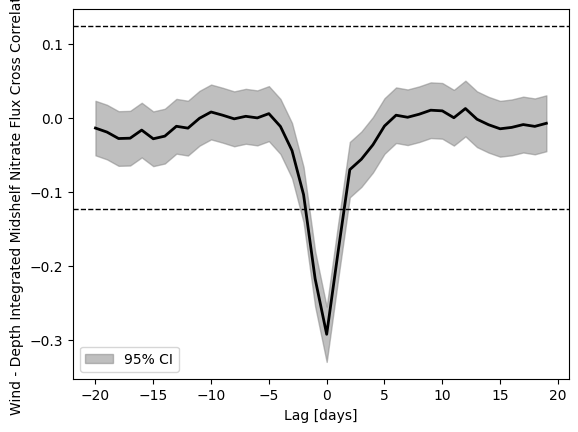

np.float64(-0.29252138788845256)

In [81]:
tdelay = np.arange(-20, 20)
flux_wind_lag_correlation, confint, n = lagged_correlation(
    midshelf_nitrate_flux_depth_integrated_monthly,
    wind["coare_y"],
    tdelay,
)

plot_correlations(
    tdelay,
    flux_wind_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind - Depth Integrated Midshelf Nitrate Flux Cross Correlation",
)

flux_wind_lag_correlation.min()

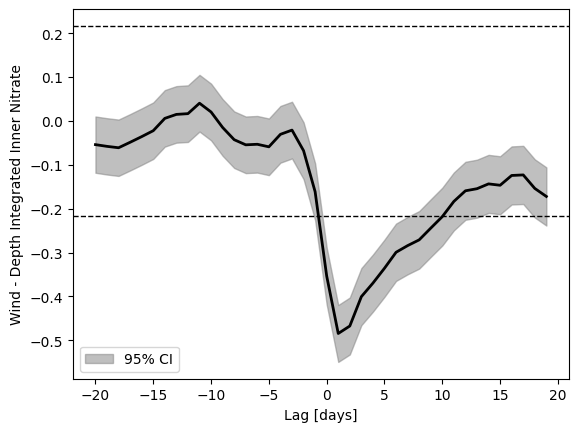

np.float64(-0.48427171062227015)

In [82]:
tdelay = np.arange(-20, 20)
flux_wind_lag_correlation, confint, n = lagged_correlation(
    inner_nitrate["depth_integrated_nitrate"],
    wind["coare_y"],
    tdelay,
)

plot_correlations(
    tdelay,
    flux_wind_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind - Depth Integrated Inner Nitrate",
)

flux_wind_lag_correlation.min()

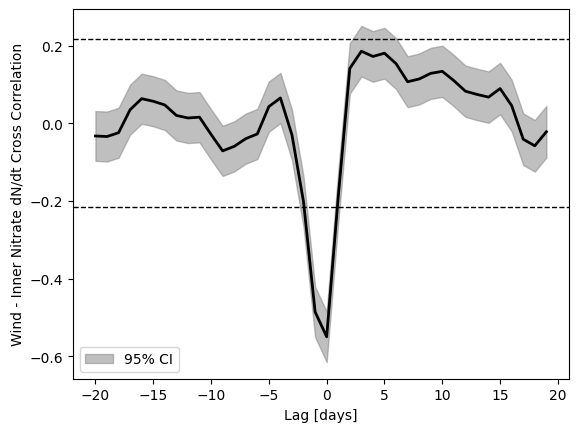

np.float64(-0.5492850446075038)

In [83]:
tdelay = np.arange(-20, 20)
flux_wind_lag_correlation, confint, n = lagged_correlation(
    inner_nitrate["dndt_volume_integrated"],
    wind["coare_y"],
    tdelay,
)

plot_correlations(
    tdelay,
    flux_wind_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind - Inner Nitrate dN/dt Cross Correlation",
)

flux_wind_lag_correlation.min()

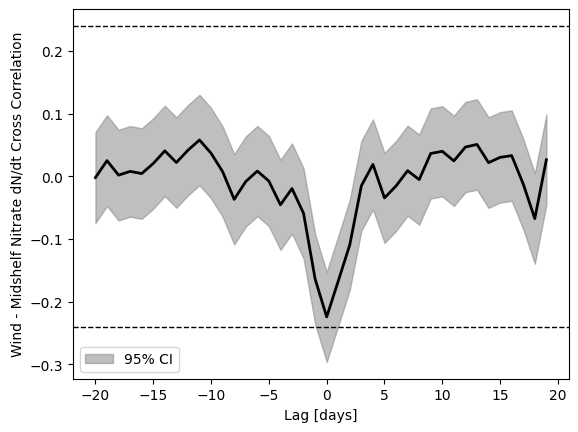

np.float64(-0.2242312397098762)

In [84]:
tdelay = np.arange(-20, 20)
flux_wind_lag_correlation, confint, n = lagged_correlation(
    midshelf_nitrate["dndt_volume_integrated"],
    wind["coare_y"],
    tdelay,
)

plot_correlations(
    tdelay,
    flux_wind_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind - Midshelf Nitrate dN/dt Cross Correlation",
)

flux_wind_lag_correlation.min()

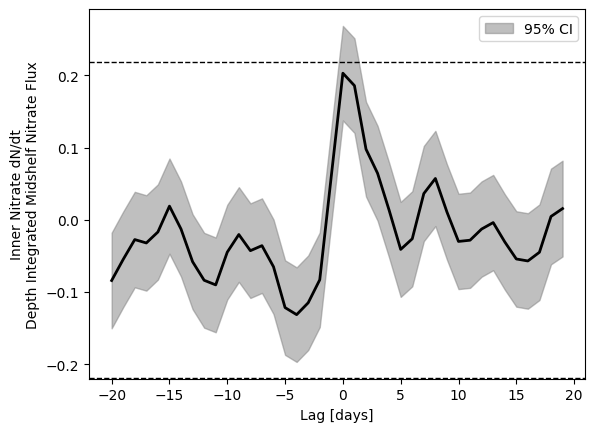

In [85]:
temp_flux, temp_inner, temp_mid = xr.align(
    midshelf_nitrate_flux_depth_integrated_monthly,
    inner_nitrate.dropna("depth", how="all"),
    midshelf_nitrate.dropna("depth", how="all"),
)

flux_nitrate_lag_correlation, confint, n = lagged_correlation(
    temp_flux,
    (temp_inner["dndt_volume_integrated"]),
    tdelay,
)

plot_correlations(
    tdelay,
    flux_nitrate_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Inner Nitrate dN/dt\nDepth Integrated Midshelf Nitrate Flux",
)

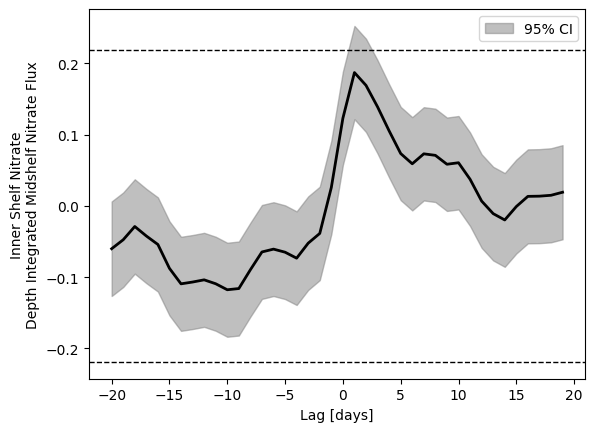

In [86]:
flux_nitrate_lag_correlation, confint, n = lagged_correlation(
    inner_nitrate["nitrate"].mean(dim="depth"),
    midshelf_nitrate_flux_depth_integrated_monthly,
    tdelay,
)

plot_correlations(
    tdelay,
    flux_nitrate_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Inner Shelf Nitrate\nDepth Integrated Midshelf Nitrate Flux",
)

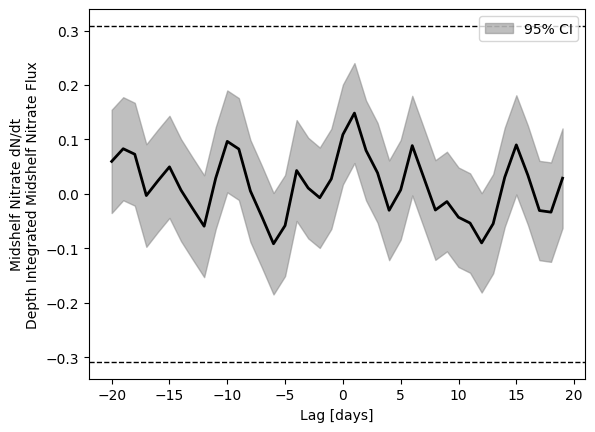

In [87]:
tdelay = np.arange(-20, 20)
flux_dndt_lag_correlation, confint, n = lagged_correlation(
    midshelf_nitrate["dndt_volume_integrated"],
    midshelf_nitrate_flux_depth_integrated_monthly,
    tdelay,
)

plot_correlations(
    tdelay,
    flux_dndt_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Midshelf Nitrate dN/dt\nDepth Integrated Midshelf Nitrate Flux",
)

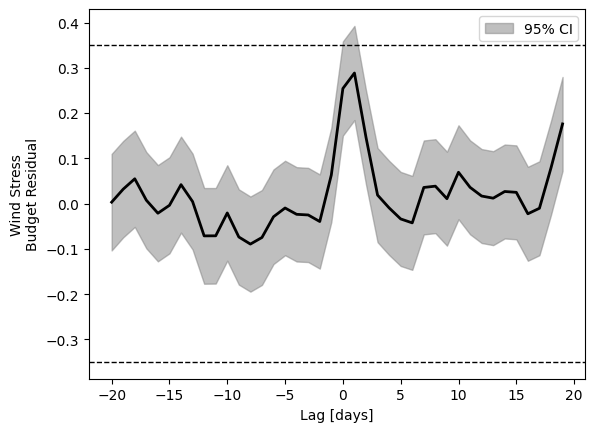

In [88]:
temp_flux, temp_inner, temp_mid = xr.align(
    midshelf_nitrate_flux_depth_integrated,
    inner_nitrate.dropna("depth", how="all"),
    midshelf_nitrate.dropna("depth", how="all"),
)
tdelay = np.arange(-20, 20)
flux_dndt_lag_correlation, confint, n = lagged_correlation(
    wind.coare_y,
    (temp_flux - temp_inner["dndt_volume_integrated"] - temp_mid["dndt_volume_integrated"]),
    tdelay,
)

plot_correlations(
    tdelay,
    flux_dndt_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind Stress\nBudget Residual",
)

In [89]:
# correlation between nitrate flux calculated using in situ vs monthly mean mid shelf nitrate
temp_flux, temp_monthly_flux = xr.align(
    midshelf_nitrate_flux_depth_integrated_monthly,
    midshelf_nitrate_flux_depth_integrated,
)
mask = ~np.isnan(temp_flux) & ~np.isnan(temp_monthly_flux)
np.corrcoef(temp_flux[mask], temp_monthly_flux[mask])

array([[1.        , 0.95752542],
       [0.95752542, 1.        ]])

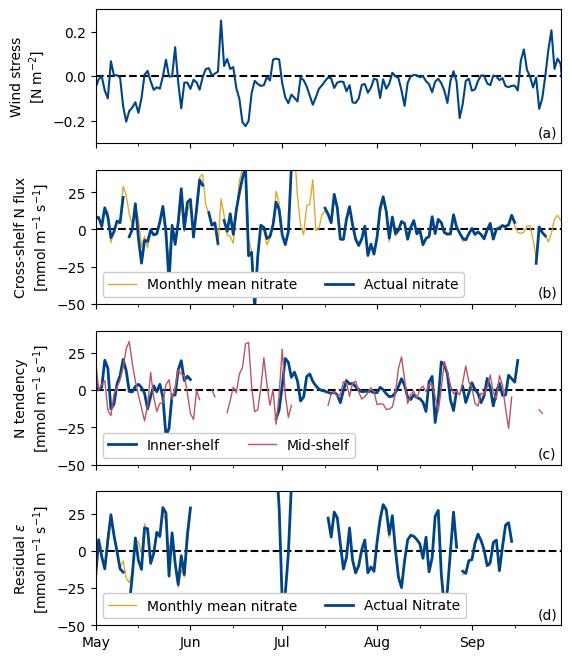

In [90]:
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(6, 8))
axs[0].set_xlim(np.datetime64("2021-05-01"), np.datetime64("2021-09-30"))

midshelf_nitrate_flux_depth_integrated_monthly = midshelf_nitrate_flux_depth_integrated_monthly.resample(
    time="1D",
).mean()
midshelf_nitrate_flux_depth_integrated = midshelf_nitrate_flux_depth_integrated.resample(time="1D").mean()
inner_nitrate = inner_nitrate.resample(time="1D").mean()
midshelf_nitrate = midshelf_nitrate.resample(time="1D").mean()

axs[0].axhline(0, ls="--", color="black")
axs[0].plot(wind["time"], wind["coare_y"], color="#004488")
axs[0].set_ylim(-0.3, 0.3)
axs[0].set_ylabel("Wind stress\n[$\\mathsf{N \\; m^{-2}}$]")


axs[1].axhline(0, ls="--", color="black")
axs[1].plot(
    midshelf_nitrate_flux_depth_integrated_monthly["time"],
    midshelf_nitrate_flux_depth_integrated_monthly,
    label="Monthly mean nitrate",
    color="#DDAA33",
    linewidth=1,
)
axs[1].plot(
    midshelf_nitrate_flux_depth_integrated["time"],
    midshelf_nitrate_flux_depth_integrated,
    label="Actual nitrate",
    color="#004488",
    linewidth=2,
)
axs[1].set_ylim(-50, 40)
axs[1].set_ylabel("Cross-shelf N flux\n[$\\mathsf{mmol \\; m^{-1} \\; s^{-1}}$]")
axs[1].legend(facecolor="white", frameon=True, framealpha=1, ncols=2, loc="lower left")

axs[2].axhline(0, ls="--", color="black")
axs[2].plot(
    inner_nitrate.time,
    inner_nitrate["dndt_volume_integrated"],
    color="#004488",
    label="Inner-shelf",
    linewidth=2,
)
axs[2].plot(
    midshelf_nitrate.time,
    midshelf_nitrate["dndt_volume_integrated"],
    c="#BB5566",
    label="Mid-shelf",
    linewidth=1,
)
axs[2].set_ylim(-50, 40)
axs[2].set_ylabel("N tendency\n[$\\mathsf{mmol \\; m^{-1} \\; s^{-1}}$]")
axs[2].legend(facecolor="white", frameon=True, framealpha=1, ncols=2, loc="lower left")


axs[3].axhline(0, ls="--", color="black")
temp_flux, temp_inner, temp_mid = xr.align(
    midshelf_nitrate_flux_depth_integrated_monthly,
    inner_nitrate.dropna("depth", how="all"),
    midshelf_nitrate.dropna("depth", how="all"),
)
axs[3].plot(
    temp_flux.time,
    (temp_flux - temp_inner["dndt_volume_integrated"] - temp_mid["dndt_volume_integrated"]),
    label="Monthly mean nitrate",
    color="#DDAA33",
    linewidth=1,
)
temp_flux, temp_inner, temp_mid = xr.align(
    midshelf_nitrate_flux_depth_integrated,
    inner_nitrate.dropna("depth", how="all"),
    midshelf_nitrate.dropna("depth", how="all"),
)
axs[3].plot(
    temp_flux.time,
    (temp_flux - temp_inner["dndt_volume_integrated"] - temp_mid["dndt_volume_integrated"]),
    label="Actual Nitrate",
    color="#004488",
    linewidth=2,
)

axs[3].set_ylim(-50, 40)
axs[3].set_ylabel("Residual $\\epsilon$\n[$\\mathsf{mmol \\; m^{-1} \\; s^{-1}}$]")
axs[3].legend(facecolor="white", frameon=True, framealpha=1, ncols=2, loc="lower left")
axs[3].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axs[3].xaxis.set_major_locator(mdates.MonthLocator())
axs[3].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))


axs[0].annotate("(a)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
axs[1].annotate("(b)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
axs[2].annotate("(c)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
axs[3].annotate("(d)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
# axs[3].tick_params(axis='x', which='major', labelsize=10)

plt.savefig(
    FIGURES_DIR / f"manuscript/{FIG_SAVE_FMT}/2021_nbudget.{FIG_SAVE_FMT}",
    format=FIG_SAVE_FMT,
    bbox_inches="tight",
    dpi=600,
)

## Lee et al. 200? Budget Method

In [ ]:
inner_volume = calculate_budget_volume(
    xr.DataArray(1),  # for input of 1, we get the volume of the control volume in m^3
    d_min=-7,
    d_max=0,
    d_step=0.1,
    lon_min=-130,
    lon_max=-120,
    lat=44.66,
)
mid_volume = calculate_budget_volume(
    xr.DataArray(1),  # for input of 1, we get the volume of the control volume in m^3
    d_min=-18.5,
    d_max=-7,
    d_step=0.1,
    lon_min=-130,
    lon_max=-120,
    lat=44.66,
)

mean_nitrate = (
    inner_nitrate["nitrate"].mean(dim="depth") * inner_volume
    + midshelf_nitrate["nitrate"].mean(dim="depth") * mid_volume
) / (inner_volume + mid_volume)

In [ ]:
# calculate midshelf flux by interpolating nan and filling ends with constant extrapolation
midshelf_nitrate_interp = xr.concat(
    [
        yi.interpolate_na(
            "depth",
            fill_value=[yi.dropna("depth")[0], yi.dropna("depth")[-1]],
        )
        for yi in midshelf_nitrate.nitrate
        if yi.dropna("depth").size > 40  # only use profiles with more than 40 depth points
    ],
    "time",
)
cs_al_midnitr, midnitr_al_cs, mean_nitrate_al_cs = xr.align(
    velocity.cs.dropna("time", how="all"),
    midshelf_nitrate_interp,
    mean_nitrate.dropna("time", how="all"),
)
midshelf_nitrate_flux_depth_integrated = xr.apply_ufunc(
    lambda x, y: np.array(
        [np.trapezoid(yi[~np.isnan(yi)], x[~np.isnan(yi)]) for yi in y],
    ),
    cs_al_midnitr.depth.values,
    (cs_al_midnitr * (midnitr_al_cs - mean_nitrate_al_cs)).values,
)
midshelf_nitrate_flux_depth_integrated = xr.DataArray(
    midshelf_nitrate_flux_depth_integrated,
    {"time": cs_al_midnitr.time},
)
midshelf_nitrate_flux_depth_integrated_filtered = xr.DataArray(
    median_filter(
        midshelf_nitrate_flux_depth_integrated.values,
        size=5,
    ),
    {"time": midshelf_nitrate_flux_depth_integrated.time},
)

In [98]:
mean_nitrate_monthly = mean_nitrate.groupby("time.month").mean(dim="time", skipna=True)

# use monthly N profiles to calculate nitrate flux for correlation
midshelf_nitrate_flux_monthly_flux_list = [
    velocity.where(velocity["time.month"] == month, drop=True).cs
    * (midshelf_nitrate_monthly["mean"].sel(month=month) - mean_nitrate_monthly.sel(month=month))
    for month in range(4, 10)
]
midshelf_nitrate_flux_monthly_flux = xr.merge(
    [v.to_dataset(name="nitrate_flux").drop_vars("month") for v in midshelf_nitrate_flux_monthly_flux_list],
)

midshelf_nitrate_flux_depth_integrated_monthly = xr.apply_ufunc(
    lambda x, y: np.array(
        [np.trapezoid(yi[~np.isnan(yi)], x[~np.isnan(yi)]) if len(yi[~np.isnan(yi)]) > 40 else np.nan for yi in y],
    ),
    midshelf_nitrate_flux_monthly_flux["depth"].values,
    midshelf_nitrate_flux_monthly_flux["nitrate_flux"].values,
)
midshelf_nitrate_flux_depth_integrated_monthly = xr.DataArray(
    midshelf_nitrate_flux_depth_integrated_monthly,
    {"time": midshelf_nitrate_flux_monthly_flux.time},
)
midshelf_nitrate_flux_depth_integrated_monthly_filtered = xr.DataArray(
    median_filter(
        midshelf_nitrate_flux_depth_integrated_monthly.values,
        size=5,
    ),
    {"time": midshelf_nitrate_flux_depth_integrated_monthly.time},
)

Text(0.95, 0.05, '(d)')

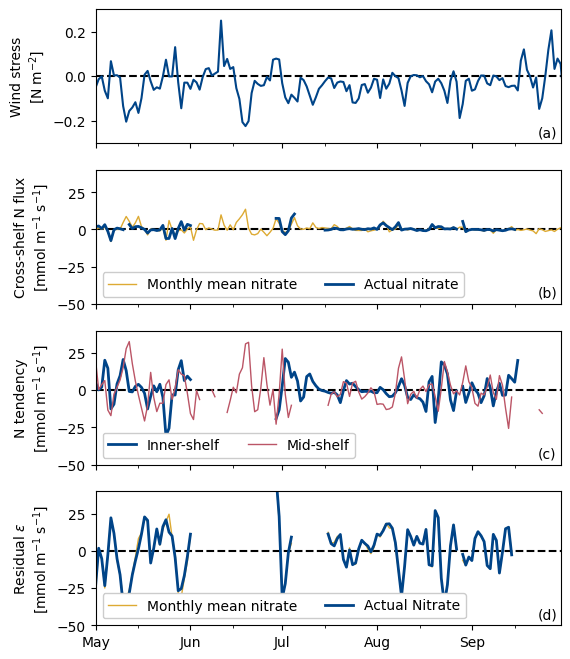

In [99]:
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(6, 8))
axs[0].set_xlim(np.datetime64("2021-05-01"), np.datetime64("2021-09-30"))

midshelf_nitrate_flux_depth_integrated_monthly = midshelf_nitrate_flux_depth_integrated_monthly.resample(
    time="1D",
).mean()
midshelf_nitrate_flux_depth_integrated = midshelf_nitrate_flux_depth_integrated.resample(time="1D").mean()
inner_nitrate = inner_nitrate.resample(time="1D").mean()
midshelf_nitrate = midshelf_nitrate.resample(time="1D").mean()

axs[0].axhline(0, ls="--", color="black")
axs[0].plot(wind["time"], wind["coare_y"], color="#004488")
axs[0].set_ylim(-0.3, 0.3)
axs[0].set_ylabel("Wind stress\n[$\\mathsf{N \\; m^{-2}}$]")


axs[1].axhline(0, ls="--", color="black")
axs[1].plot(
    midshelf_nitrate_flux_depth_integrated_monthly["time"],
    midshelf_nitrate_flux_depth_integrated_monthly,
    label="Monthly mean nitrate",
    color="#DDAA33",
    linewidth=1,
)
axs[1].plot(
    midshelf_nitrate_flux_depth_integrated["time"],
    midshelf_nitrate_flux_depth_integrated,
    label="Actual nitrate",
    color="#004488",
    linewidth=2,
)
axs[1].set_ylim(-50, 40)
axs[1].set_ylabel("Cross-shelf N flux\n[$\\mathsf{mmol \\; m^{-1} \\; s^{-1}}$]")
axs[1].legend(facecolor="white", frameon=True, framealpha=1, ncols=2, loc="lower left")

axs[2].axhline(0, ls="--", color="black")
axs[2].plot(
    inner_nitrate.time,
    inner_nitrate["dndt_volume_integrated"],
    color="#004488",
    label="Inner-shelf",
    linewidth=2,
)
axs[2].plot(
    midshelf_nitrate.time,
    midshelf_nitrate["dndt_volume_integrated"],
    c="#BB5566",
    label="Mid-shelf",
    linewidth=1,
)
axs[2].set_ylim(-50, 40)
axs[2].set_ylabel("N tendency\n[$\\mathsf{mmol \\; m^{-1} \\; s^{-1}}$]")
axs[2].legend(facecolor="white", frameon=True, framealpha=1, ncols=2, loc="lower left")


axs[3].axhline(0, ls="--", color="black")
temp_flux, temp_inner, temp_mid = xr.align(
    midshelf_nitrate_flux_depth_integrated_monthly,
    inner_nitrate.dropna("depth", how="all"),
    midshelf_nitrate.dropna("depth", how="all"),
)
axs[3].plot(
    temp_flux.time,
    (temp_flux - temp_inner["dndt_volume_integrated"] - temp_mid["dndt_volume_integrated"]),
    label="Monthly mean nitrate",
    color="#DDAA33",
    linewidth=1,
)
temp_flux, temp_inner, temp_mid = xr.align(
    midshelf_nitrate_flux_depth_integrated,
    inner_nitrate.dropna("depth", how="all"),
    midshelf_nitrate.dropna("depth", how="all"),
)
axs[3].plot(
    temp_flux.time,
    (temp_flux - temp_inner["dndt_volume_integrated"] - temp_mid["dndt_volume_integrated"]),
    label="Actual Nitrate",
    color="#004488",
    linewidth=2,
)

axs[3].set_ylim(-50, 40)
axs[3].set_ylabel("Residual $\\epsilon$\n[$\\mathsf{mmol \\; m^{-1} \\; s^{-1}}$]")
axs[3].legend(facecolor="white", frameon=True, framealpha=1, ncols=2, loc="lower left")
axs[3].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axs[3].xaxis.set_major_locator(mdates.MonthLocator())
axs[3].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))


axs[0].annotate("(a)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
axs[1].annotate("(b)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
axs[2].annotate("(c)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
axs[3].annotate("(d)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
# axs[3].tick_params(axis='x', which='major', labelsize=10)

# plt.savefig(
#     FIGURES_DIR / f"manuscript/{FIG_SAVE_FMT}/2021_nbudget.{FIG_SAVE_FMT}",
#     format=FIG_SAVE_FMT,
#     bbox_inches="tight",
#     dpi=600,
# )

In [100]:
table = Table(title="Standard Deviation Results")
table.add_column("N tendency", justify="left", no_wrap=True)
# table.add_column("Mid N tendency", justify="left", style="yellow", no_wrap=True)
table.add_column("N flux", justify="left", no_wrap=True)
table.add_column("Residual", justify="left", no_wrap=True)

table.add_row(
    f"{(temp_inner['dndt_volume_integrated'] + temp_mid['dndt_volume_integrated']).std().values:.2f}",
    f"{(midshelf_nitrate_flux_depth_integrated_monthly).std().values:.2f}",
    f"{(temp_flux - temp_inner['dndt_volume_integrated'] - temp_mid['dndt_volume_integrated']).std().values:.2f}",
)
console = Console()
console.print(table)

    Standard Deviation Results    
┏━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┓
┃ N tendency ┃ N flux ┃ Residual ┃
┡━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━┩
│ 15.05      │ 3.15   │ 14.69    │
└────────────┴────────┴──────────┘